## Lab 7

**Apply different filters to an image and observe the results.**
1. Low Pass Filter 
2. High Pass Filter 
3. Lowpass Gaussian Filter 
4. HighPass Gaussian Filter 

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def print_images(image, note):
    fig, ax = plt.subplots(2, 2, figsize=(10, 5))
    ax[0, 0].imshow(image)
    ax[0, 0].set_title(f'RGB Image {note}')
    ax[0, 0].axis('off')
    
    ax[0, 1].imshow(image[:, :, 0], cmap='gray')
    ax[0, 1].set_title(f'Red Channel {note}')
    ax[0, 1].axis('off')
    
    ax[1, 0].imshow(image[:, :, 1], cmap='gray')
    ax[1, 0].set_title(f'Green Channel {note}')
    ax[1, 0].axis('off')
    
    ax[1, 1].imshow(image[:, :, 2], cmap='gray')
    ax[1, 1].set_title(f'Blue Channel {note}')
    ax[1, 1].axis('off')
    fig.tight_layout()
    plt.show()

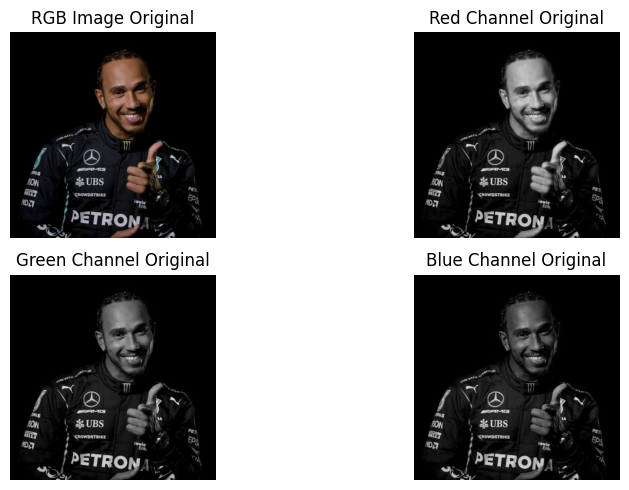

In [3]:
base_img = cv2.imread('Images/lh.jpg')
base_img = cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB)
print_images(base_img, 'Original')

In [4]:
def add_salt_and_pepper_noise(image, amount=0.02):
    """
    amount: Probability of noise (0.02 means 2% of pixels will be noisy)
    """
    output = np.copy(image)
    
    probs = np.random.random(output.shape[:2])

    output[probs < (amount / 2)] = 0

    output[(probs >= (amount / 2)) & (probs < amount)] = 255
    
    return output

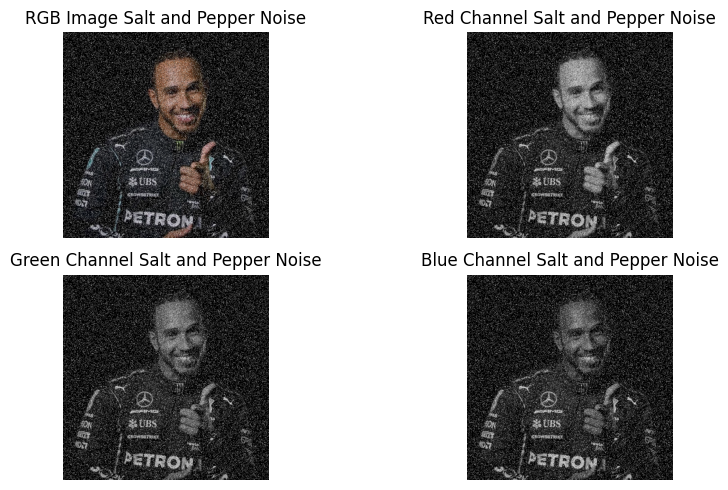

In [5]:
salt_pepper_img = add_salt_and_pepper_noise(base_img, amount=0.2)
print_images(salt_pepper_img, 'Salt and Pepper Noise')

In [6]:
def apply_filter(image, kernel):
    kh, kw = kernel.shape
    h, w, c = image.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='edge')
    
    res_img = np.zeros_like(image, dtype=np.float32)
    for i in range(h):
        for j in range(w):
            region = padded_img[i : i + kh, j : j + kw, :]
            res_img[i, j, :] = np.sum(region * kernel[:, :, np.newaxis], axis=(0, 1))
            
    return res_img

In [7]:
def low_pass_filter(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size ** 2)
    return apply_filter(image, kernel)

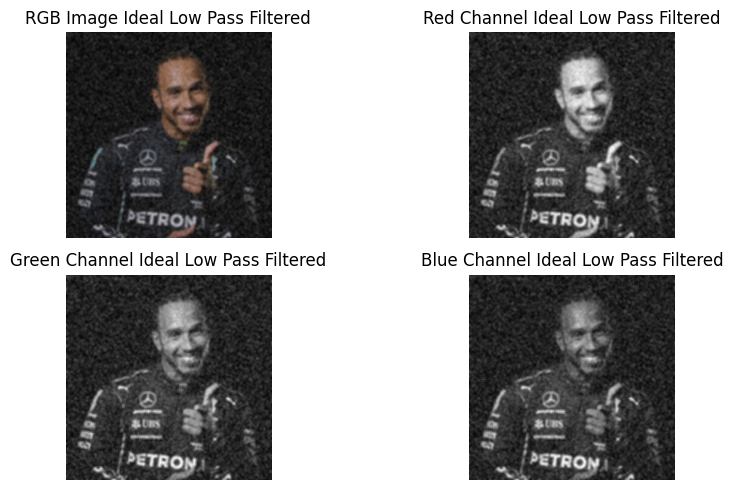

In [8]:
low_pass_img = low_pass_filter(salt_pepper_img, 10)
low_pass_img = np.clip(low_pass_img, 0, 255).astype(np.uint8)
print_images(low_pass_img, 'Ideal Low Pass Filtered')

Text(0.5, 1.0, 'High Pass Filtered Image (Ideal)')

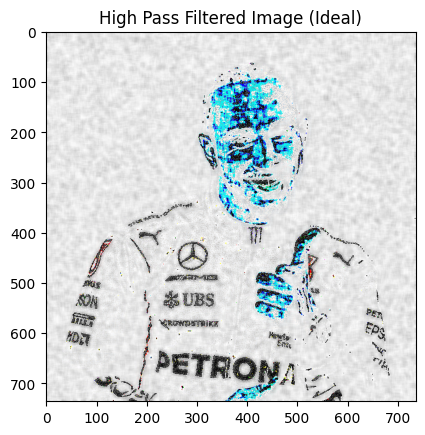

In [9]:
temp = salt_pepper_img - low_pass_img
plt.imshow(temp)
plt.title('High Pass Filtered Image (Ideal)')

In [10]:
def high_pass_filter(image, kernel_size):
    kernel = -np.ones((kernel_size, kernel_size), np.float32) / (kernel_size ** 2)
    kernel[kernel_size // 2, kernel_size // 2] = 1
    return apply_filter(image, kernel)

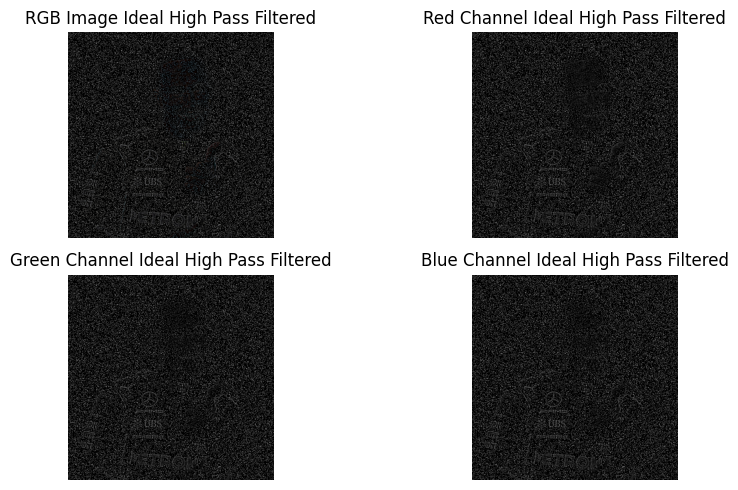

In [11]:
high_pass_img = high_pass_filter(salt_pepper_img, 10)
high_pass_img = np.clip(high_pass_img, 0, 255).astype(np.uint8)
print_images(high_pass_img, 'Ideal High Pass Filtered')

In [12]:
def low_pass_gaussian_filter(image, kernel_size, sigma):
    # Create Gaussian kernel
    ax = np.arange(-kernel_size // 2 + 1., kernel_size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel /= np.sum(kernel)
    
    return apply_filter(image, kernel)

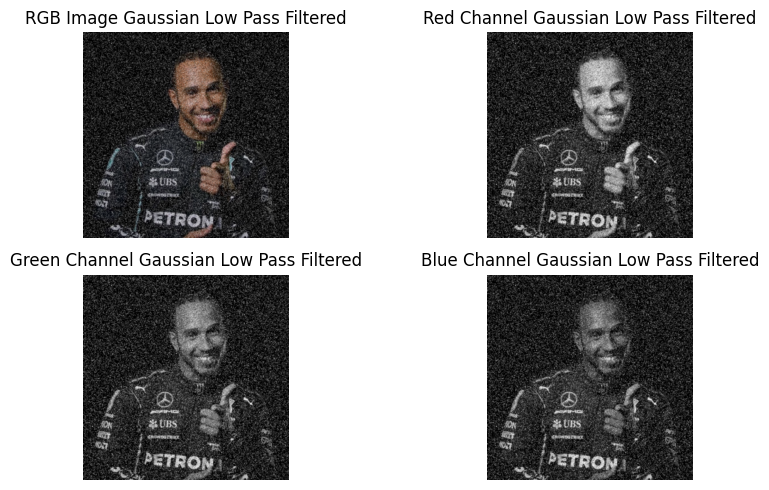

In [13]:
low_pass_gaussian_img = low_pass_gaussian_filter(salt_pepper_img, kernel_size=10, sigma=1)
low_pass_gaussian_img = np.clip(low_pass_gaussian_img, 0, 255).astype(np.uint8)
print_images(low_pass_gaussian_img, 'Gaussian Low Pass Filtered')

In [14]:
def high_pass_gaussian_filter(image, kernel_size, sigma):
    # Create Gaussian kernel
    ax = np.arange(-kernel_size // 2 + 1., kernel_size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel /= np.sum(kernel)
    
    # Create high-pass kernel
    high_pass_kernel = -kernel
    high_pass_kernel[kernel_size // 2, kernel_size // 2] += 1
    
    return apply_filter(image, high_pass_kernel)

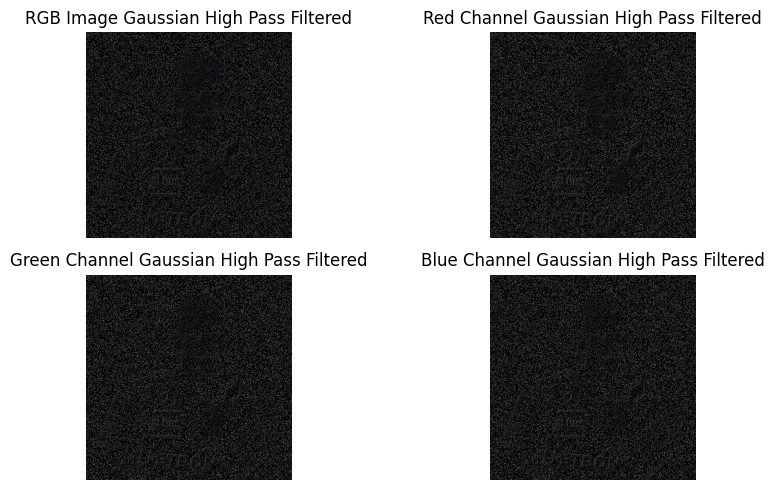

In [15]:
high_pass_gaussian_img = high_pass_gaussian_filter(salt_pepper_img, kernel_size=10, sigma=1)
high_pass_gaussian_img = np.clip(high_pass_gaussian_img, 0, 255).astype(np.uint8)
print_images(high_pass_gaussian_img, 'Gaussian High Pass Filtered')